验证所有数据归一化(在剩余总额中的比例)后是否符合理论上的均匀分布

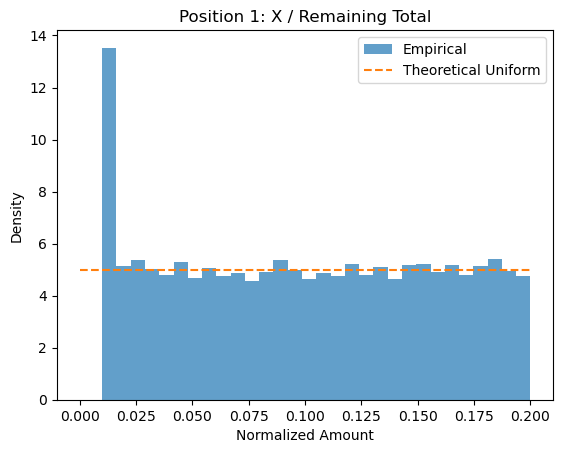

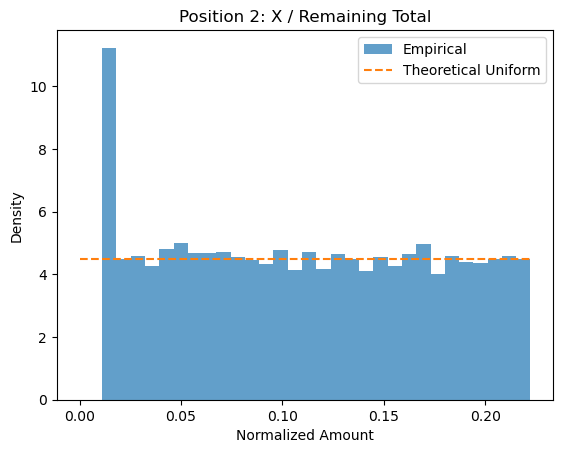

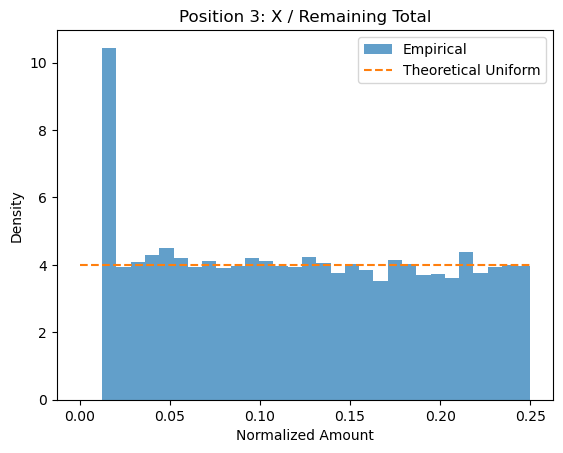

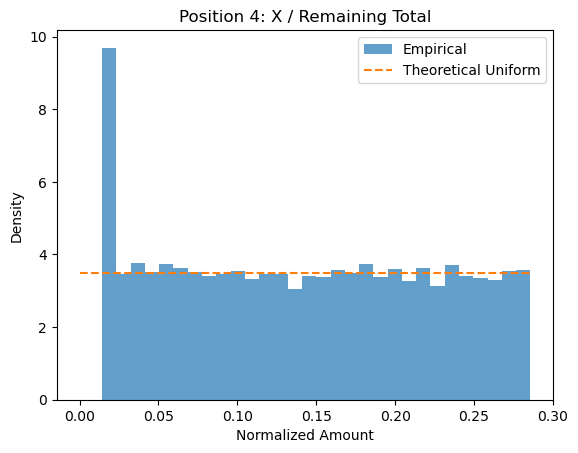

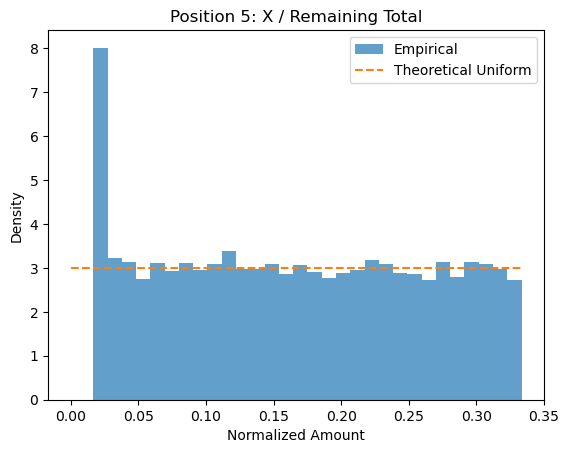

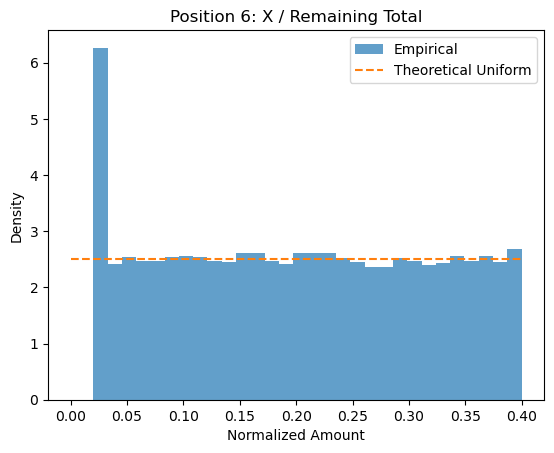

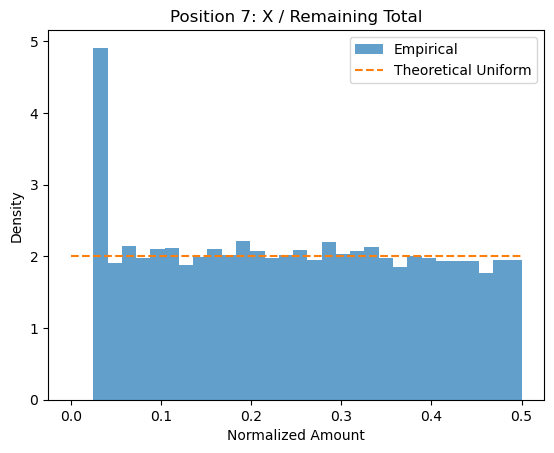

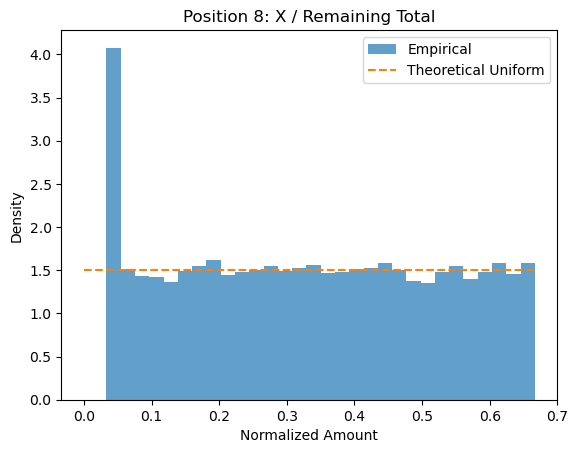

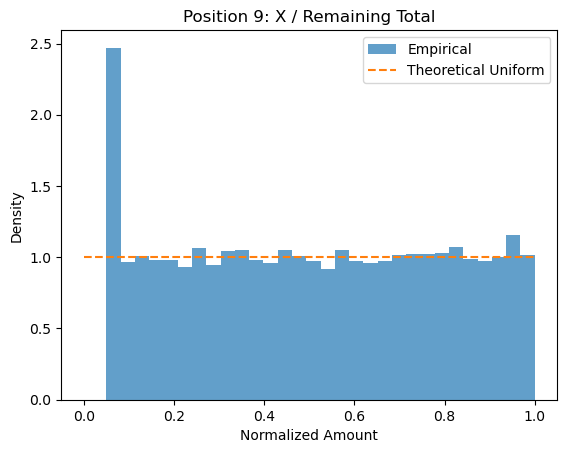

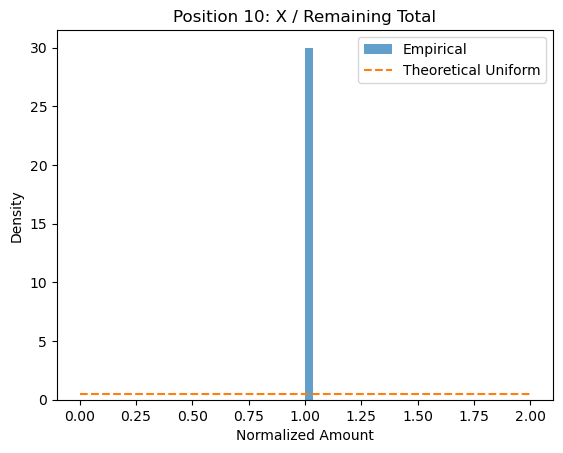

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================
# 1. 读取数据
# =====================
# 假设:
# 行 = 实验次数
# 列 = 位次 (第1个抢到的人, 第2个, ...)
df = pd.read_csv("envelopes.csv")

# Skip the 'Trial' column (first column)
df_data = df.iloc[:, 1:]

num_positions = df_data.shape[1]

# =====================
# 2. 计算归一化比例
# =====================
ratios = {}

for i, col in enumerate(df_data.columns):
    # 剩余总额（包含自己）
    remaining_sum = df_data.iloc[:, i:].sum(axis=1)
    ratios[col] = df_data[col] / remaining_sum

ratio_df = pd.DataFrame(ratios)

# =====================
# 3. 绘制直方图验证均匀分布
# =====================
for i, col in enumerate(ratio_df.columns):
    plt.figure()
    plt.hist(
        ratio_df[col],
        bins=30,
        density=True,
        alpha=0.7,
        label="Empirical"
    )

    # 理论均匀分布上界
    upper = 2 / (num_positions - i) 

    x = np.linspace(0, upper, 200)
    y = np.ones_like(x) / upper
    plt.plot(x, y, linestyle="--", label="Theoretical Uniform")

    plt.title(f"Position {i+1}: X / Remaining Total")
    plt.xlabel("Normalized Amount")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

K-S检验

In [71]:
from scipy.stats import kstest

print("Kolmogorov–Smirnov Test Results")
print("-" * 50)

for i, col in enumerate(ratio_df.columns):
    # 理论均匀分布的上界
    upper = 2 / (num_positions - i)

    # 经验样本
    data = ratio_df[col].dropna().values

    # KS 检验
    # H0: data ~ Uniform(0, upper)
    ks_stat, p_value = kstest(
        data,
        'uniform',
        args=(0, upper)
    )

    print(
        f"Position {i+1:2d} | "
        f"KS statistic = {ks_stat:.4f} | "
        f"p-value = {p_value:.4f}"
    )


Kolmogorov–Smirnov Test Results
--------------------------------------------------
Position  1 | KS statistic = 0.0500 | p-value = 0.0000
Position  2 | KS statistic = 0.0500 | p-value = 0.0000
Position  3 | KS statistic = 0.0500 | p-value = 0.0000
Position  4 | KS statistic = 0.0500 | p-value = 0.0000
Position  5 | KS statistic = 0.0500 | p-value = 0.0000
Position  6 | KS statistic = 0.0500 | p-value = 0.0000
Position  7 | KS statistic = 0.0500 | p-value = 0.0000
Position  8 | KS statistic = 0.0500 | p-value = 0.0000
Position  9 | KS statistic = 0.0500 | p-value = 0.0000
Position 10 | KS statistic = 0.5000 | p-value = 0.0000


第二个人抢到金额的实际分布：

[13.19  8.32 11.23 ... 15.94 20.85  1.67]
Total amount m = 99.99625
Participant Number n= 10
Max empirical X2 = 21.93
Theoretical upper bound = 22.22138888888889
A= 0.05020918189001807
x_flat= 17.77711111111111
C= 0.2250084378164181


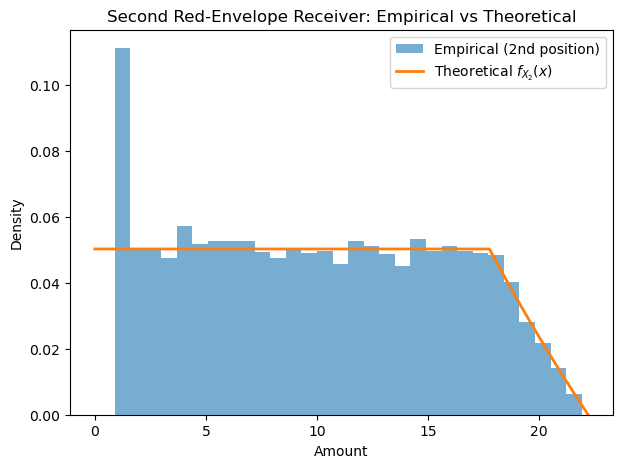

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# =====================
# 基本参数
# =====================
# 第二个抢红包的数据
x2_data = df.iloc[:-1, 2].values
print(x2_data)

n = df.shape[1]-1                      # 人数
m = df.sum(axis=1, numeric_only=True).iloc[1]  # 总金额（从第一行取得）
print("Total amount m =", m)
print("Participant Number n=", n)
print("Max empirical X2 =", x2_data.max())
print("Theoretical upper bound =", 2 * m / (n - 1))


# =====================
# 理论 PDF 定义
# =====================
def f_X2(x, n, m):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)

    a = 2 * m * (n - 2) / (n * (n - 1))
    b = 2 * m / (n - 1)
    c = n * (n - 1) / (4 * m)

    mask1 = (x >= 0) & (x <= a)
    pdf[mask1] = c * np.log(n / (n - 2))

    mask2 = (x > a) & (x <= b)
    pdf[mask2] = c * np.log((2 * m) / ((n - 1) * x[mask2]) )

    print("A=",c * np.log(n / (n - 2)))
    print("x_flat=",a)
    print("C=",c)

    return pdf

# =====================
# 作图：经验直方图 + 理论曲线
# =====================
x_grid = np.linspace(0, 2 * m / (n - 1), 500)
pdf_vals = f_X2(x_grid, n, m)

plt.figure(figsize=(7,5))
plt.hist(
    x2_data,
    bins=30,
    density=True,
    alpha=0.6,
    label="Empirical (2nd position)"
)

plt.plot(
    x_grid,
    pdf_vals,
    linewidth=2,
    label=r"Theoretical $f_{X_2}(x)$"
)

plt.xlabel("Amount")
plt.ylabel("Density")
plt.title("Second Red-Envelope Receiver: Empirical vs Theoretical")
plt.legend()
plt.show()

随着$i$的增加，解析式会包含更高阶的多重对数或多项式，形式极其复杂。但我们可以定性描述其分布特征：
期望值不变： 数学上可以证明，对于任意 $1\le i \le n$，都有$$E[X_i]=\frac{m}{n}$$

方差增大：$i=1$时是均匀分布，方差最小，只能取到平均值的0到2倍。

$i$越大，剩余金额$S_i$的不确定性越大。后面的人有可能面临“前面的人抢很少，剩下一大笔钱”（从而抢到远超2倍均值的金额），也有可能面临“前面的人抢完了，只剩渣”（抢到0）。

分布图会变得**低而宽**，即取值范围变大，但概率密度峰值降低。

验证$X_k$的PDF

1.计算参数

In [78]:
def theoretical_params_Xk(k, n, m):
    # x_flat^{(k)}
    prod = 1.0
    for i in range(k - 1):
        prod *= (n - i - 2) / (n - i)
    x_flat = (2 * m / (n - k + 1)) * prod

    # 平坦区高度 A_k
    A = (n * (n - k + 1) / (4 * m)) * np.log((n - k + 2) / (n - k))

    # 理论上界
    c = 2 * m / (n - k + 1)

    # 连续性条件确定 C_k
    C = A / (np.log(c / x_flat) ** (k - 1))

    return A, x_flat, C, c


2.理论PDF

In [79]:
def f_Xk(x, k, n, m):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)

    A, x_flat, C, c = theoretical_params_Xk(k, n, m)

    mask1 = (x >= 0) & (x <= x_flat)
    pdf[mask1] = A

    mask2 = (x > x_flat) & (x <= c)
    pdf[mask2] = C * (np.log(c / x[mask2]) ** (k - 1))

    return pdf


3.验证第k个红包：经验 vs 理论

In [80]:
def validate_Xk(df, k, bins=30):
    # 第 k 个红包数据
    xk_data = df.iloc[:-1, k].values

    n = df.shape[1] - 1
    m = df.sum(axis=1, numeric_only=True).iloc[1]

    A, x_flat, C, c = theoretical_params_Xk(k, n, m)

    print(f"=== X_{k} theoretical parameters ===")
    print("A =", A)
    print("x_flat =", x_flat)
    print("c =", c)
    print("C =", C)
    print("Empirical max =", xk_data.max())

    x_grid = np.linspace(0, c, 600)
    pdf_vals = f_Xk(x_grid, k, n, m)

    plt.figure(figsize=(7, 5))
    plt.hist(
        xk_data,
        bins=bins,
        density=True,
        alpha=0.6,
        label=f"Empirical (position {k})"
    )
    plt.plot(
        x_grid,
        pdf_vals,
        linewidth=2,
        label=rf"Theoretical $f_{{X_{k}}}(x)$"
    )

    plt.axvline(x_flat, linestyle="--", color="black", alpha=0.7,
                label=r"$x_{\mathrm{flat}}$")

    plt.xlabel("Amount")
    plt.ylabel("Density")
    plt.title(f"Position {k}: Empirical vs Theoretical")
    plt.legend()
    plt.show()


=== X_2 theoretical parameters ===
A = 0.05020918189001807
x_flat = 17.77711111111111
c = 22.22138888888889
C = 0.2250084378164181
Empirical max = 21.93


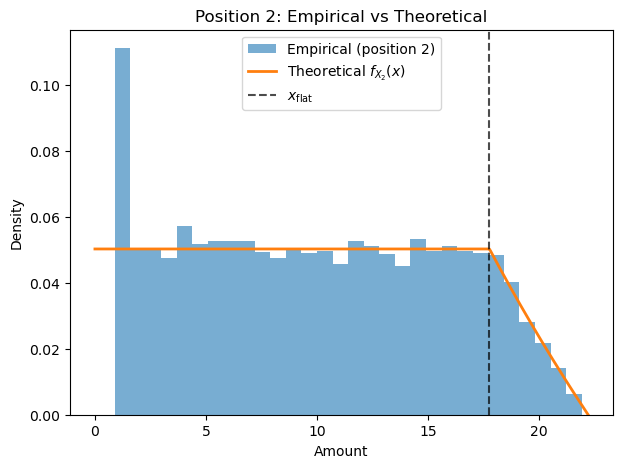

=== X_3 theoretical parameters ===
A = 0.050264770585078174
x_flat = 15.554972222222222
c = 24.9990625
C = 0.22328944509430768
Empirical max = 23.9


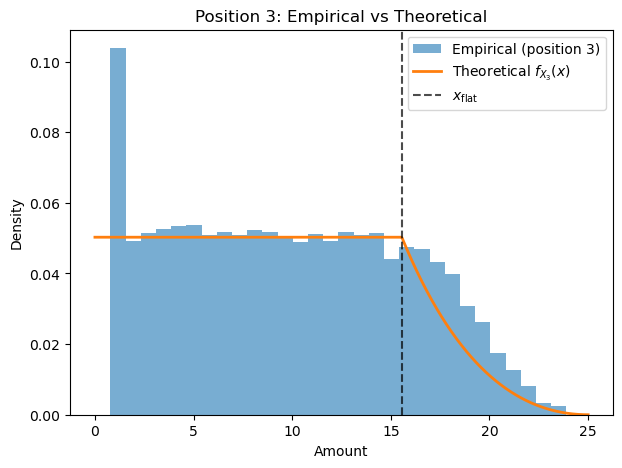

=== X_4 theoretical parameters ===
A = 0.050346250663461524
x_flat = 13.332833333333335
c = 28.570357142857144
C = 0.11372678913614852
Empirical max = 26.72


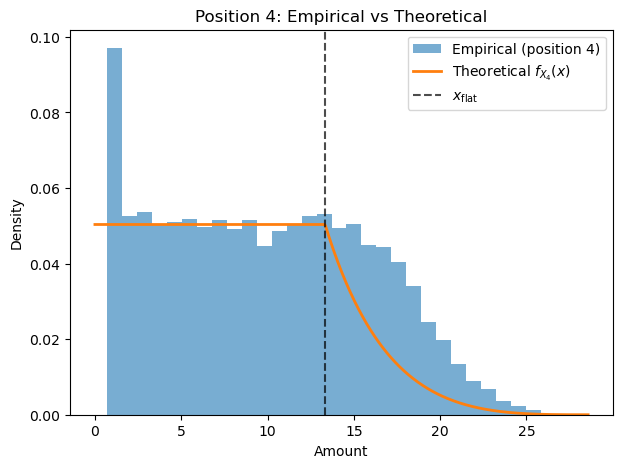

=== X_5 theoretical parameters ===
A = 0.0504727282204902
x_flat = 11.110694444444446
c = 33.33208333333334
C = 0.034648063779848526
Empirical max = 29.9


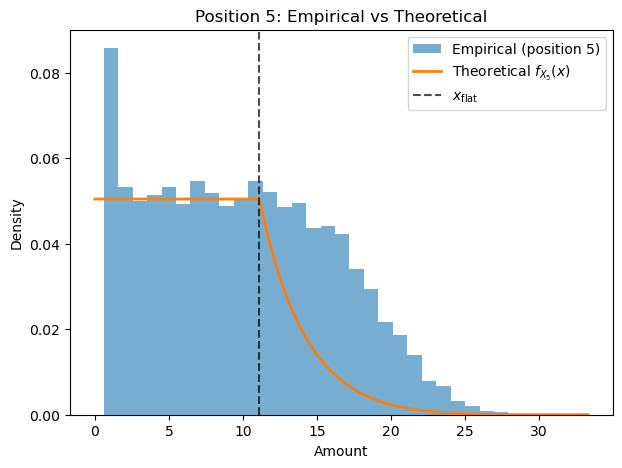

=== X_6 theoretical parameters ===
A = 0.050685039202490643
x_flat = 8.888555555555556
c = 39.9985
C = 0.006584591893849711
Empirical max = 33.28


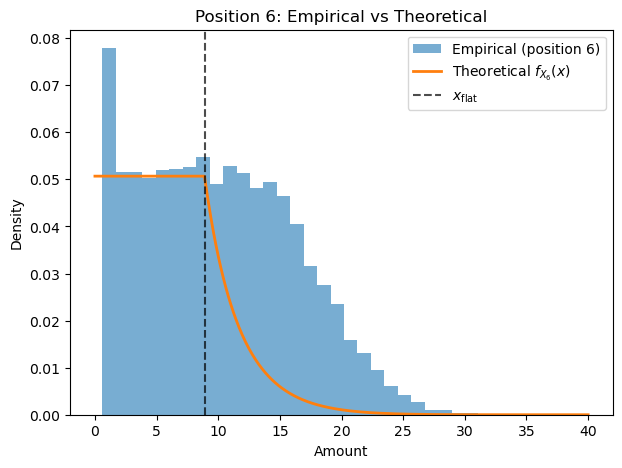

=== X_7 theoretical parameters ===
A = 0.05108447804452574
x_flat = 6.666416666666667
c = 49.998125
C = 0.0007634209482937072
Empirical max = 39.5


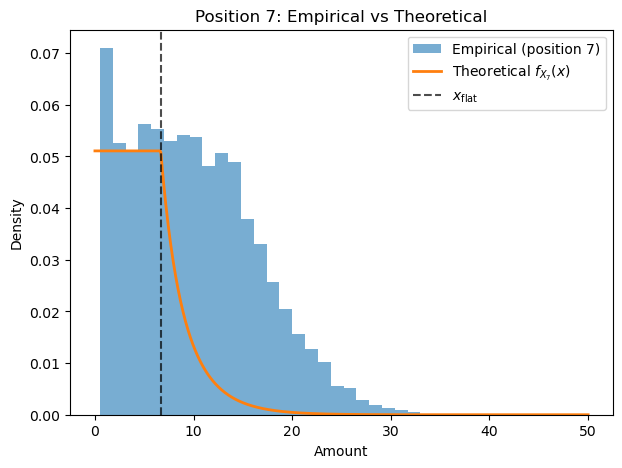

=== X_8 theoretical parameters ===
A = 0.05198798809154933
x_flat = 4.444277777777778
c = 66.66416666666667
C = 4.8675008309889104e-05
Empirical max = 47.36


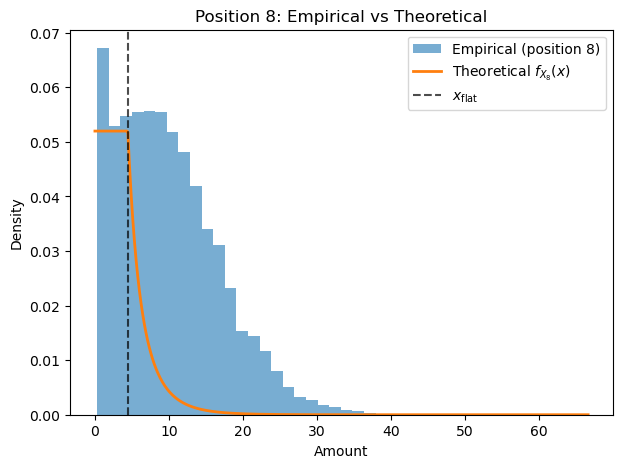

=== X_9 theoretical parameters ===
A = 0.054932674408695814
x_flat = 2.222138888888889
c = 99.99625
C = 1.2458787027675559e-06
Empirical max = 59.93


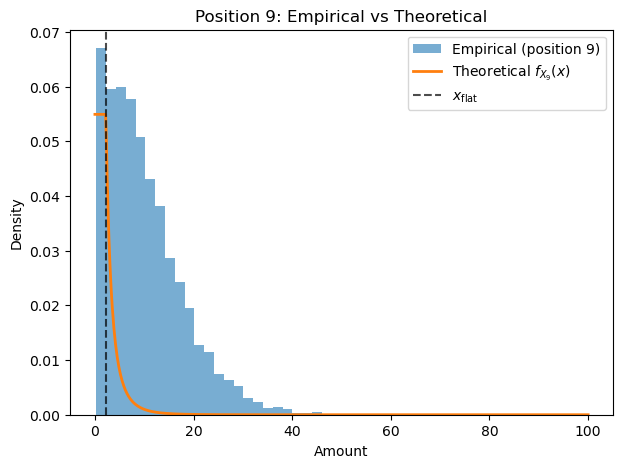

ZeroDivisionError: division by zero

In [83]:
validate_Xk(df, k=2)
validate_Xk(df, k=3)
validate_Xk(df, k=4)
validate_Xk(df, k=5)
validate_Xk(df, k=6)
validate_Xk(df, k=7)
validate_Xk(df, k=8)
validate_Xk(df, k=9)
validate_Xk(df, k=10)
